# Proyecto final 
## Objetivo
Crear un sistema de recomendación que dados:
- nivel de estudios
- años de experiencia
- especilización en IA

Se pueda recomendar: 
- El tipo de trabajo al que aspirar
- La cantidad de salario

# Importe de librerias

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

## Selección del data set
Hemos elegido un data set enfocado a trabajos en ai y data de varios paises. Los datos son encuestas a usuarios y cada fila es un usuario. 

In [194]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/global-ai-and-data-jobs-salary-dataset")

# Exploracion del dataset

In [195]:
df = pd.read_csv(f"{path}/global_ai_jobs.csv")  

In [196]:
df.shape

(90000, 35)

In [197]:
df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [198]:
df['job_role'].value_counts()

job_role
NLP Engineer                 11412
Software Engineer AI         11333
Research Scientist           11309
Machine Learning Engineer    11263
AI Engineer                  11247
Computer Vision Engineer     11227
Data Scientist               11146
Data Analyst                 11063
Name: count, dtype: int64

Elegimos los años dede el 2022 - 2026 para tener información más reciente, debido a que el sector tecnológico avanza a pasos de gigante y pensamos que información de hace 6 años no benificiaria nuestro predictor

In [199]:
#cambiar el año
df_2part = df[df["year"] >= 2022].copy()
df_2part.shape

(64229, 35)

In [200]:
df_2part.isnull().sum()

id                         0
country                    0
job_role                   0
ai_specialization          0
experience_level           0
experience_years           0
salary_usd                 0
bonus_usd                  0
education_required         0
industry                   0
company_size               0
interview_rounds           0
year                       0
work_mode                  0
weekly_hours               0
company_rating             0
job_openings               0
hiring_difficulty_score    0
layoff_risk                0
ai_adoption_score          0
company_funding_billion    0
economic_index             0
ai_maturity_years          0
offer_acceptance_rate      0
tax_rate_percent           0
vacation_days              0
skill_demand_score         0
automation_risk            0
job_security_score         0
career_growth_score        0
work_life_balance_score    0
promotion_speed            0
salary_percentile          0
cost_of_living_index       0
employee_satis

In [201]:
df_2part.duplicated().sum()

np.int64(0)

Hemos analizado cada una de las columnas de valores del dataset, entendemos que son valiosas para ciertos analisis, y estudios pero para el modelo de recomendacion que queremos realizar son datos que no son relevantes. 

Las columnas a eliminar son:
- id — Identificador
- bonus_usd — Bonus en dólares
- industry — Industria / Sector
- interview_rounds — Rondas de entrevista
- job_openings — Ofertas de trabajo disponibles
- company_rating — Valoración de la empresa
- hiring_difficulty_score — Puntuación de dificultad de contratación
- economic_index — Índice económico
- layoff_risk — Riesgo de despido
- ai_maturity_years — Años de madurez en IA
- offer_acceptance_rate — Tasa de aceptación de ofertas
- tax_rate_percent — Porcentaje de impuestos
- cost_of_living_index — Índice de coste de vida
- salary_percentile — Percentil salarial
- vacation_days — Días de vacaciones
- job_security_score — Puntuación de seguridad laboral
- career_growth_score — Puntuación de crecimiento profesional
- work_life_balance_score — Puntuación de conciliación laboral
- company_funding_billion — Financiación de la empresa (en miles de millones)
- promotion_speed — Velocidad de promoción
- skill_demand_score — Puntuación de demanda de habilidades
- automation_risk — Riesgo de automatización

In [202]:
df_2part.drop(columns=["id","bonus_usd", "industry", "interview_rounds", "job_openings", "company_rating", "hiring_difficulty_score", "economic_index", "layoff_risk","ai_maturity_years", "offer_acceptance_rate", "tax_rate_percent", "cost_of_living_index", "salary_percentile", "vacation_days", "job_security_score", "career_growth_score", "work_life_balance_score", "company_funding_billion", "promotion_speed", "skill_demand_score", "automation_risk"], inplace=True)

In [203]:
df_2part.shape

(64229, 13)

In [204]:
df_2part.info()

<class 'pandas.DataFrame'>
Index: 64229 entries, 3 to 89999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                64229 non-null  str    
 1   job_role               64229 non-null  str    
 2   ai_specialization      64229 non-null  str    
 3   experience_level       64229 non-null  str    
 4   experience_years       64229 non-null  int64  
 5   salary_usd             64229 non-null  int64  
 6   education_required     64229 non-null  str    
 7   company_size           64229 non-null  str    
 8   year                   64229 non-null  int64  
 9   work_mode              64229 non-null  str    
 10  weekly_hours           64229 non-null  float64
 11  ai_adoption_score      64229 non-null  int64  
 12  employee_satisfaction  64229 non-null  int64  
dtypes: float64(1), int64(5), str(7)
memory usage: 10.4 MB


Observamos que el dataset que tenemos ha quedado finalmente con 13 columnas con variables tanto de texto como numéricas, con las que procederemos a trabajar con el EDA

# Analisis univariante

### Variables categoricas

las cuales son `country`, `job_role`, `ai_specialization`, `experience_level`, `education_required`, `company_size`, `work_mode`

In [205]:
print(df_2part["country"].value_counts())
print(df_2part["job_role"].value_counts())
print(df_2part["ai_specialization"].value_counts())
print(df_2part["experience_level"].value_counts())
print(df_2part["education_required"].value_counts())
print(df_2part["company_size"].value_counts())
print(df_2part["work_mode"].value_counts())

country
Brazil         5444
Canada         5428
Australia      5425
Germany        5415
Singapore      5393
UAE            5383
UK             5378
Netherlands    5355
India          5295
France         5290
USA            5258
Japan          5165
Name: count, dtype: int64
job_role
NLP Engineer                 8144
Software Engineer AI         8084
AI Engineer                  8059
Machine Learning Engineer    8056
Computer Vision Engineer     8026
Research Scientist           8000
Data Scientist               7968
Data Analyst                 7892
Name: count, dtype: int64
ai_specialization
LLM                       8224
Computer Vision           8179
Analytics                 8051
MLOps                     8001
Reinforcement Learning    8000
Generative AI             7968
NLP                       7937
Forecasting               7869
Name: count, dtype: int64
experience_level
Senior    16200
Lead      16065
Mid       16000
Entry     15964
Name: count, dtype: int64
education_required
B

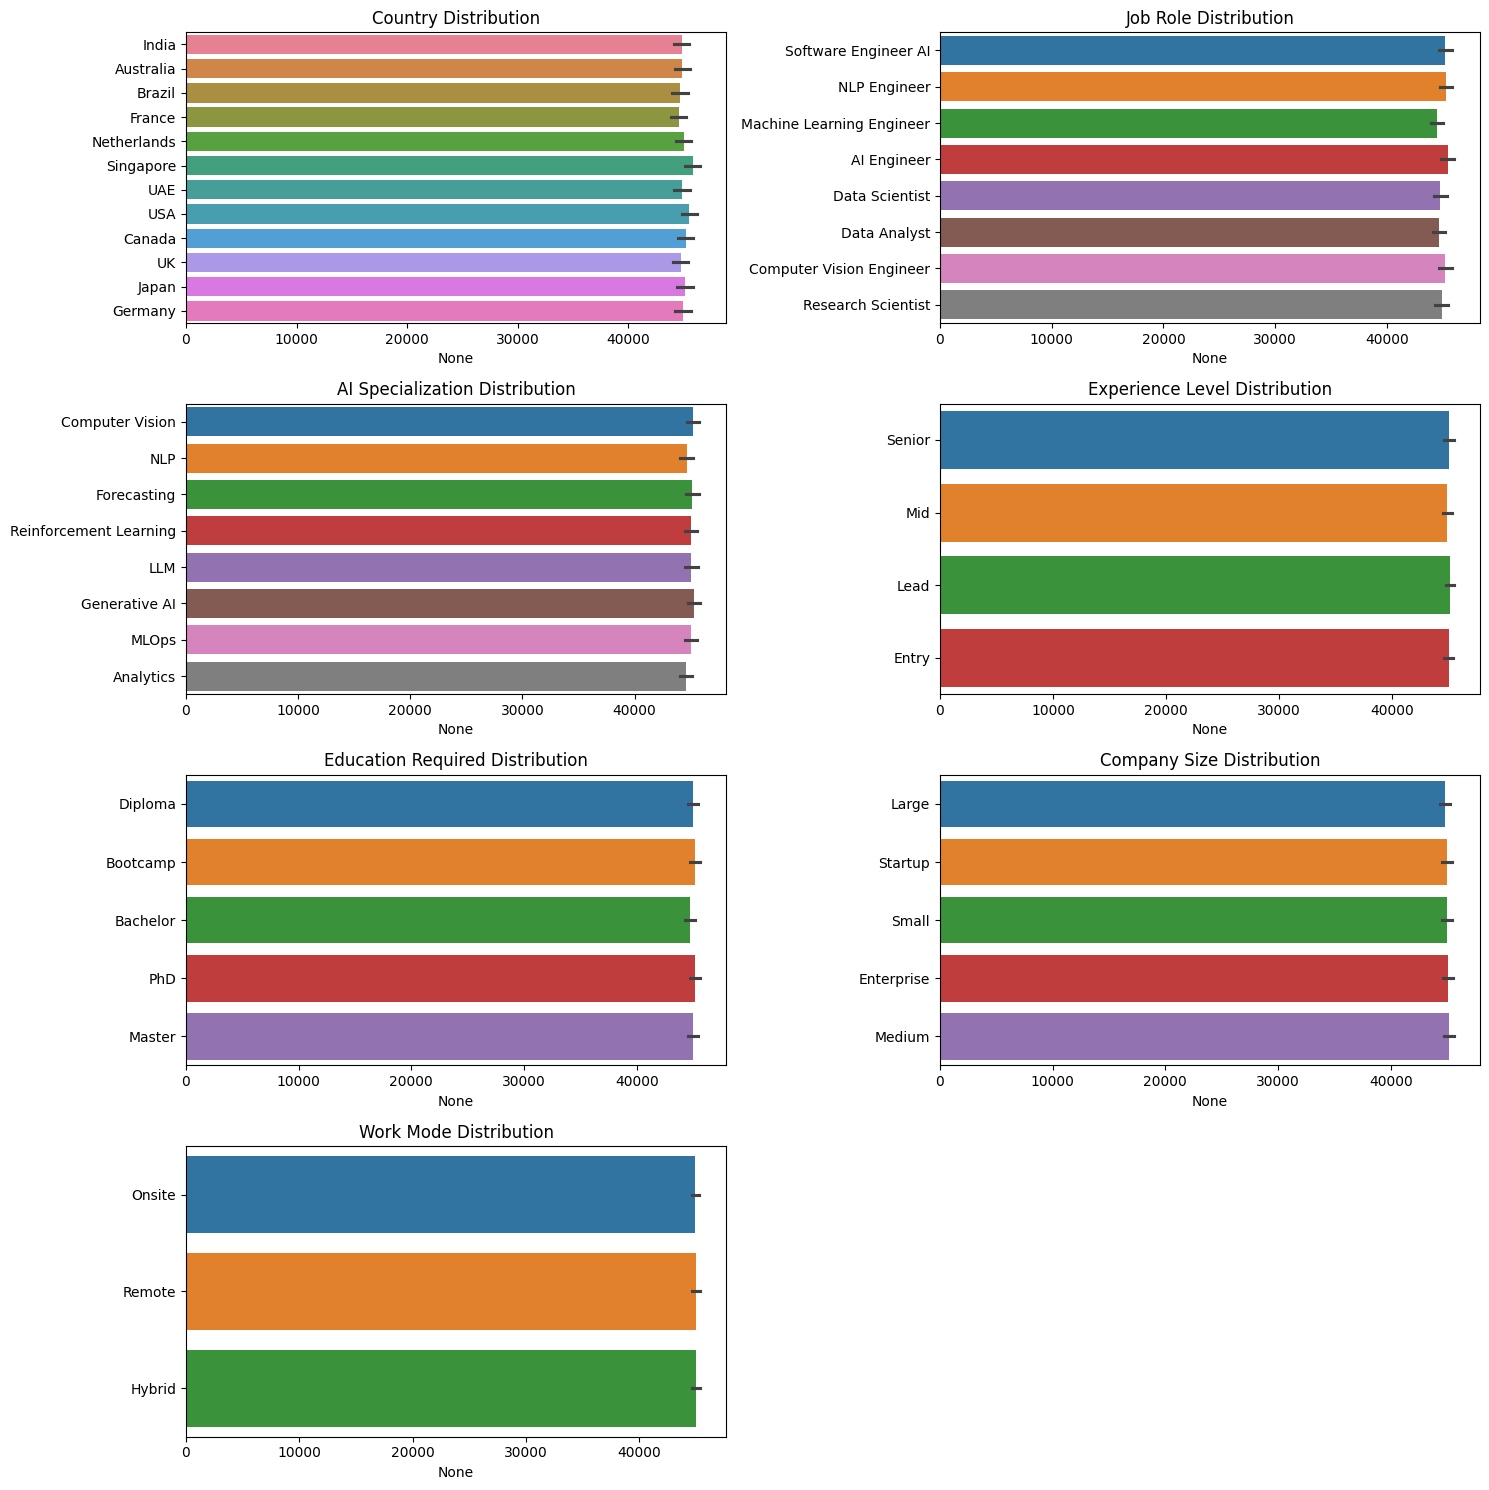

In [206]:
var_cat = ["country","job_role", "ai_specialization", "experience_level", "education_required", "company_size", "work_mode"]

fig, axis = plt.subplots(4, 2, figsize=(15, 15))

sns.barplot(ax =axis[0][0], data=df_2part, y=df_2part["country"].values, x=df_2part["country"].index,  hue=df_2part["country"].values)
axis[0][0].set_title("Country Distribution")
sns.barplot(ax =axis[0][1], data=df_2part, y=df_2part["job_role"].values, x=df_2part["job_role"].index,  hue=df_2part["job_role"].values)
axis[0][1].set_title("Job Role Distribution")
sns.barplot(ax =axis[1][0], data=df_2part, y=df_2part["ai_specialization"].values, x=df_2part["ai_specialization"].index, hue=df_2part["ai_specialization"].values)
axis[1][0].set_title("AI Specialization Distribution")
sns.barplot(ax =axis[1][1], data=df_2part, y=df_2part["experience_level"].values, x=df_2part["experience_level"].index, hue=df_2part["experience_level"].values)
axis[1][1].set_title("Experience Level Distribution")
sns.barplot(ax =axis[2][0], data=df_2part, y=df_2part["education_required"].values, x=df_2part["education_required"].index, hue=df_2part["education_required"].values)
axis[2][0].set_title("Education Required Distribution")
sns.barplot(ax =axis[2][1], data=df_2part, y=df_2part["company_size"].values, x=df_2part["company_size"].index, hue=df_2part["company_size"].values)
axis[2][1].set_title("Company Size Distribution")
sns.barplot(ax =axis[3][0], data=df_2part, y=df_2part["work_mode"].values, x=df_2part["work_mode"].index, hue=df_2part["work_mode"].values)
axis[3][0].set_title("Work Mode Distribution")

fig.delaxes(axis[3][1])

plt.tight_layout()
plt.show()

### Observaciones

En todas las graficas podemos observar que tenemos casi las mismas cantidades en cada uno de los valores. Concluyendo que el dataset está bastante equilibrado entre todas las variables categóricas.

## Variables numericas

In [207]:
df_2part.head()

,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,education_required,company_size,year,work_mode,weekly_hours,ai_adoption_score,employee_satisfaction
3,India,Software Engineer AI,Computer Vision,Senior,6,43268,Diploma,Large,2026,Onsite,52.2,74,56
5,India,Software Engineer AI,NLP,Mid,3,37712,Bootcamp,Startup,2022,Remote,48.3,59,63
8,Australia,NLP Engineer,Forecasting,Senior,10,153176,Bachelor,Small,2024,Remote,52.9,54,85
9,Brazil,Machine Learning Engineer,Forecasting,Lead,19,102716,Bootcamp,Enterprise,2023,Onsite,40.8,77,83
10,France,Software Engineer AI,NLP,Entry,1,62612,Diploma,Large,2026,Onsite,46.5,76,61


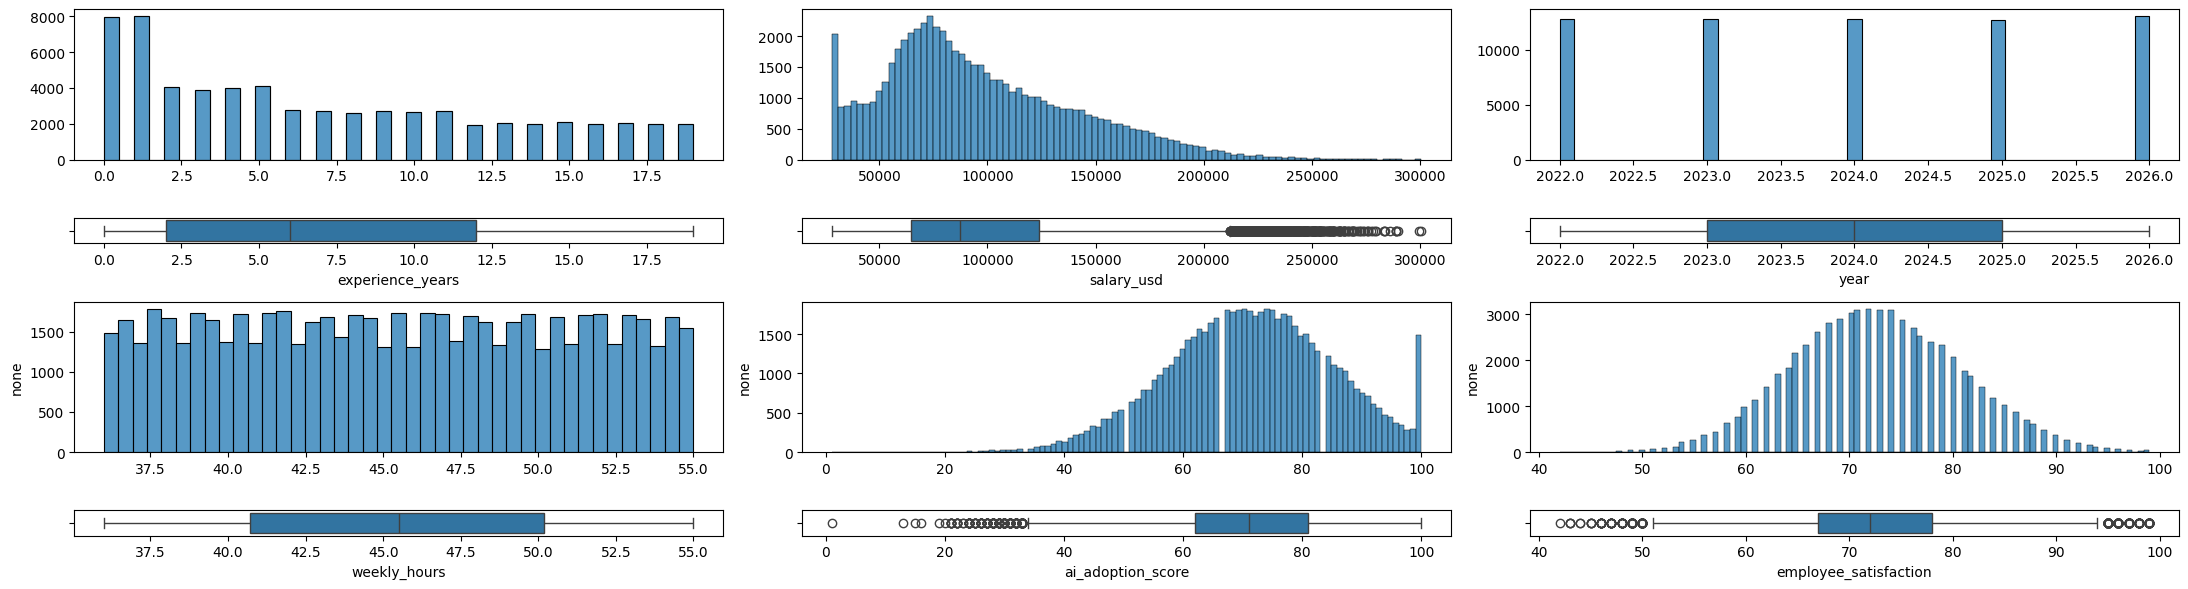

In [208]:
var_num = ['experience_years', 'salary_usd','year', 'weekly_hours', 'ai_adoption_score', 'employee_satisfaction']

fig, axis = plt.subplots(4, 3, figsize=(22, 6), gridspec_kw={'height_ratios': [6, 1, 6, 1]})

for i, var in enumerate(var_num):
    if  i < 3:
        sns.histplot(ax=axis[0, i], data=df_2part, x=var).set(xlabel=None)
        sns.boxplot(ax=axis[1, i], data=df_2part, x=var)
        axis[0, i].set(ylabel=None)
    elif i >= 3 and i < 6:
        col_idx = i - 3
        sns.histplot(ax=axis[2, col_idx], data=df_2part, x=var).set(xlabel=None)
        sns.boxplot(ax=axis[3, col_idx], data=df_2part, x=var)
        axis[2, col_idx].set(ylabel="none")


plt.tight_layout()
plt.show()

### Observaciones

- Con respecto a `experience_year` observamos que hay bastante cantidad entre lkos 0 - 2.5 años  y luego va disminuyendo poco a poco hasta los 18 años aprox. de experiencia.
- `Salary_usd` esta bastante bien distribuido entre los 50k y los 120k anuales.
- `Year` es una variable categorica numerica y esta bien distribuida.
- `weekly_hours` esta bastante variado entre las cantidades de horas trabajadas a la semana, mas adelante veremos como afecta a nivel sueldo anual.
- `ai_adoption_score`, se puede observasr claramente que la mayoria esta entre un 60 - 80% de uso y adopcion de inteligencia artificial, teniendo tambien un parte considerable que es 100%.
- Se puede observar que la satisfaccion de los empleados ronda entre el 65% y casi el 80%, teniando algunos pocos de mas de eso y menos.

## Análisis multivariante

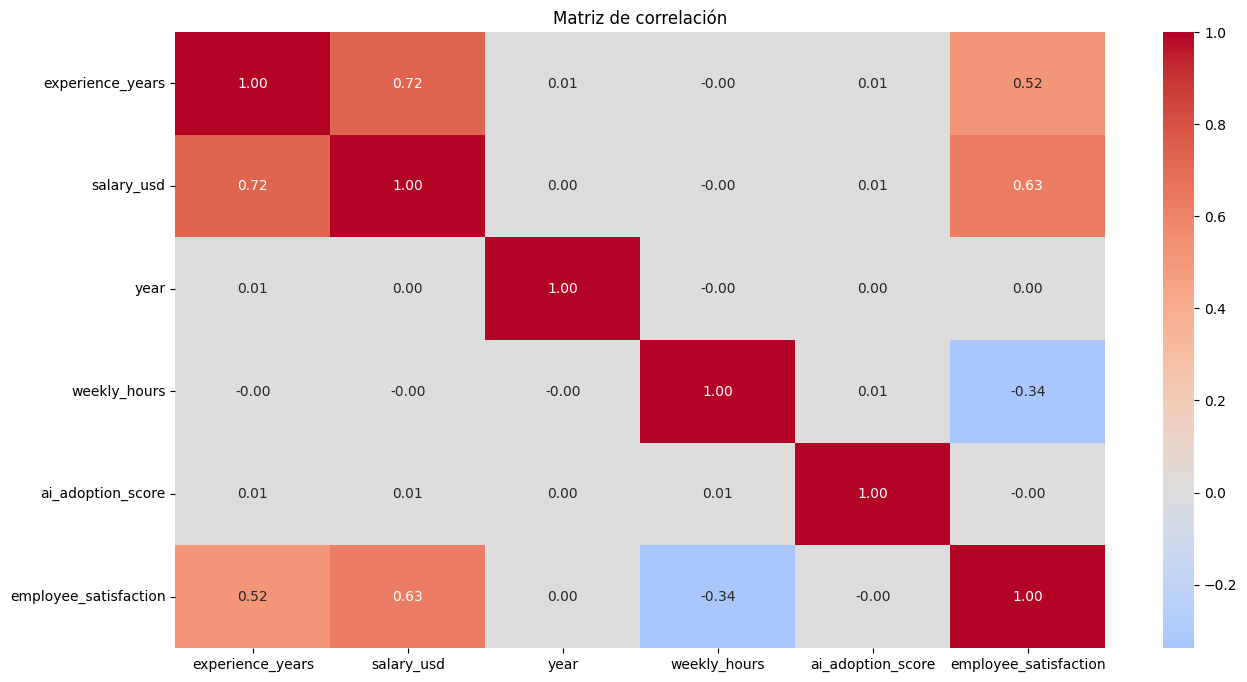

In [209]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_2part.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

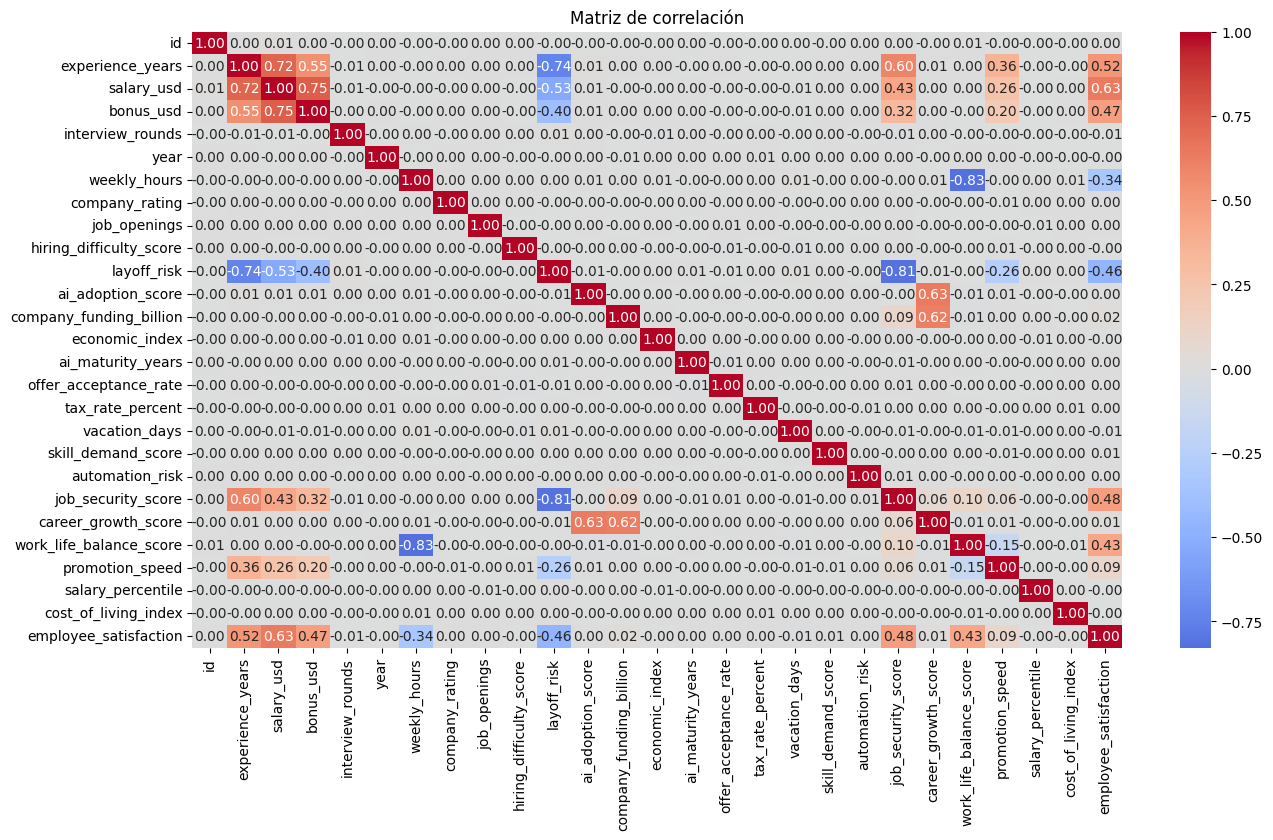

In [210]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

Hacemos los dos gráficos de calor para ver la correlación de las variables. Como nuestro objetivo es predecir el salario en función a los años de experiencia, educación y especialización en ia, el primer gráfico nos sirve para sacar conclusiones, aunque en el global tengamos más información.

El salario está fuertemente relacionado con la experiencia y la satisfacción del empleado. 
La satisfacción tienee una relación negativa con las horas semanales. 

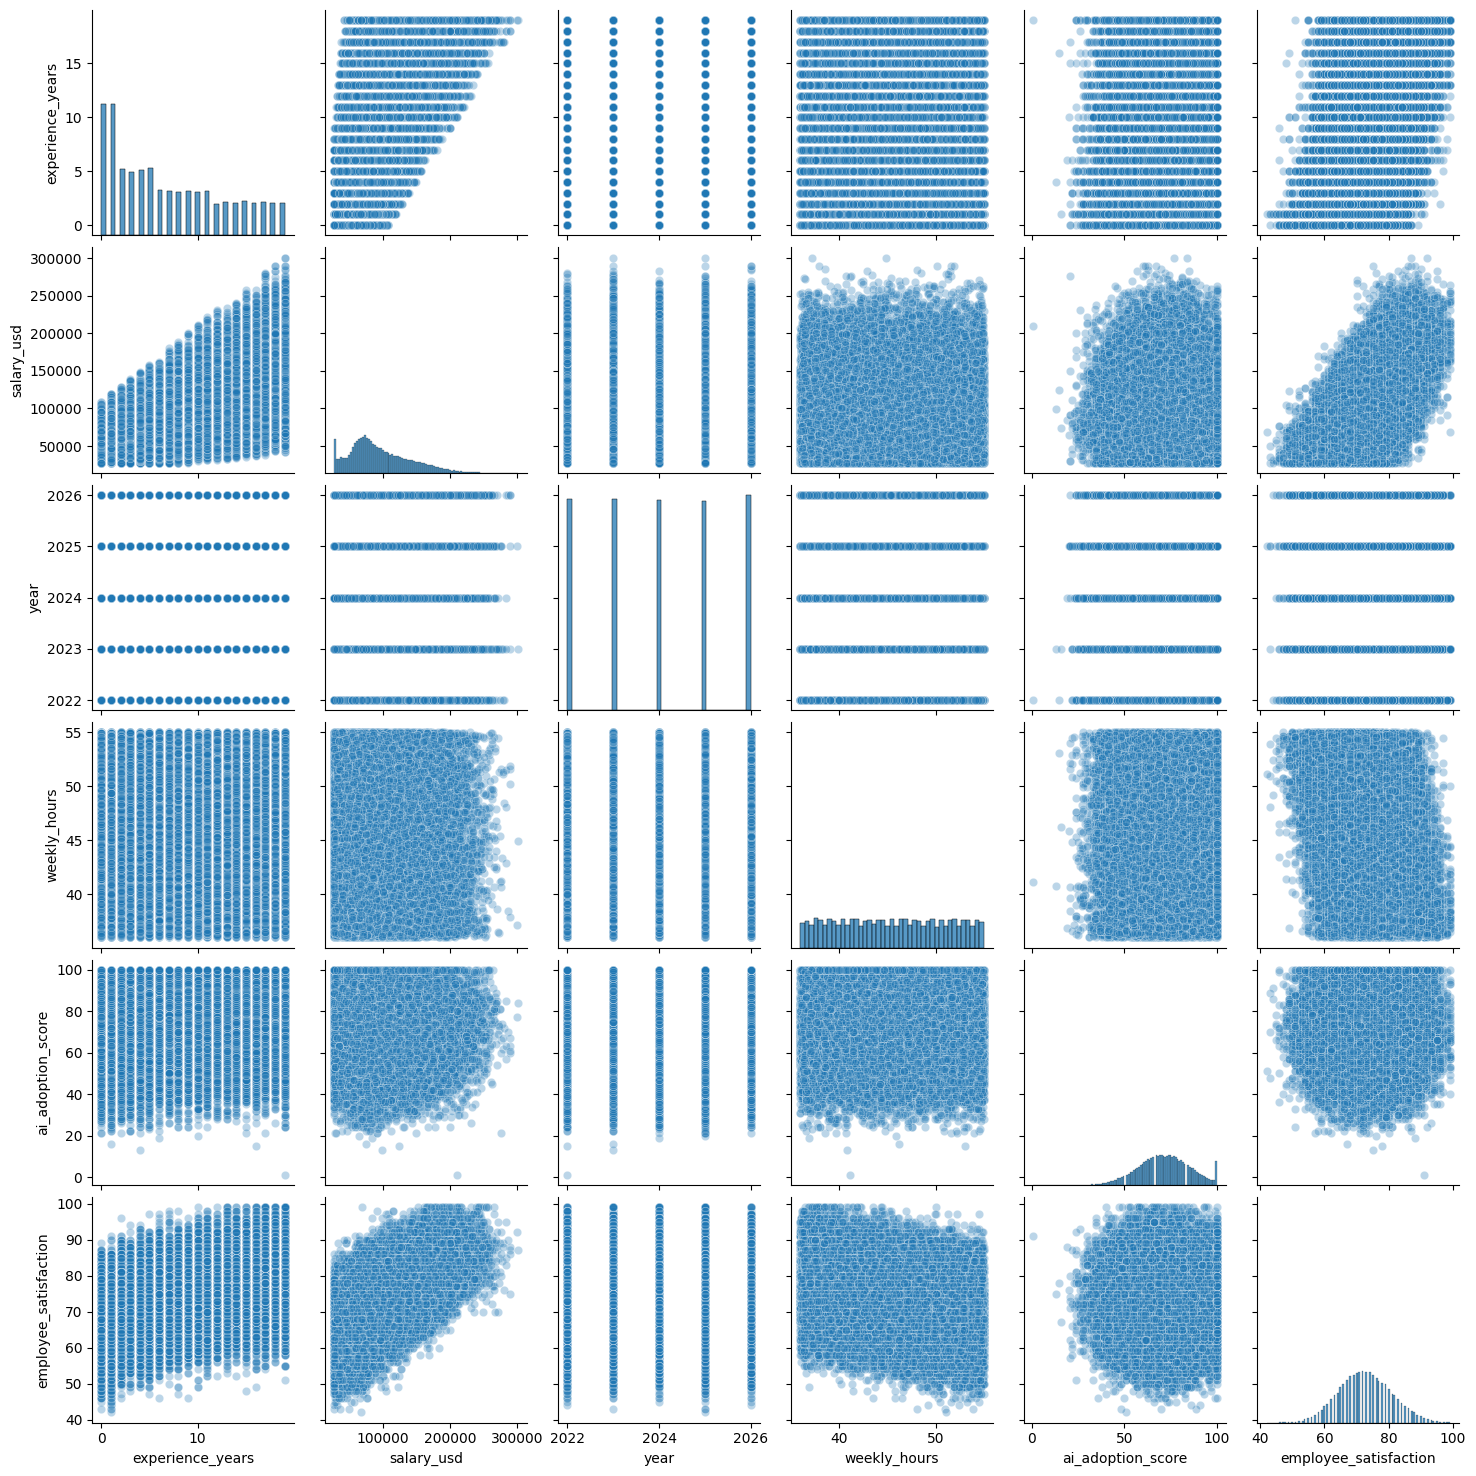

In [211]:
sns.pairplot(data=df_2part[var_num], plot_kws={"alpha": 0.3})
plt.show()

La mayoría de variables no muestran correlación lineal clara entre sí. Los scatters aparecen como nubes densas sin patrón definido.


In [212]:
df_2part.describe()

,experience_years,salary_usd,year,weekly_hours,ai_adoption_score,employee_satisfaction
count,64229.000000,64229.000000,64229.000000,64229.000000,64229.000000,64229.000000
mean,7.019181,96450.371094,2024.005480,45.479466,71.372277,72.706270
std,5.884462,43964.735836,1.418128,5.481258,13.758837,8.129229
min,0.000000,28000.000000,2022.000000,36.000000,1.000000,42.000000
25%,2.000000,64626.000000,2023.000000,40.700000,62.000000,67.000000
50%,6.000000,87389.000000,2024.000000,45.500000,71.000000,72.000000
75%,12.000000,123682.000000,2025.000000,50.200000,81.000000,78.000000
max,19.000000,300622.000000,2026.000000,55.000000,100.000000,99.000000


Vemos en el .describe no vemos cifras que nos parezcan raras. Aunque hemos visto en los gráficos analizados anteriormente un par de outliers, decidimos dejarlos.

## Transformación de variables

Convertimos: `experiencie_level`, `education_required`, `company_size` con encoding porque las variables tienenun orden de importancia

El resto con One-hot enconding dado que no tienen orden. 

Analizado ya todos los datos y escogidos las variables con las que vamos a trabajar, eliminamos `year` ya que nos sirvió para hacer el primer filtrado, pero en el modelo no nos es necesario

In [213]:
df_2part = df_2part.drop(['year'], axis=1)
df_2part.head()

,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,education_required,company_size,work_mode,weekly_hours,ai_adoption_score,employee_satisfaction
3,India,Software Engineer AI,Computer Vision,Senior,6,43268,Diploma,Large,Onsite,52.2,74,56
5,India,Software Engineer AI,NLP,Mid,3,37712,Bootcamp,Startup,Remote,48.3,59,63
8,Australia,NLP Engineer,Forecasting,Senior,10,153176,Bachelor,Small,Remote,52.9,54,85
9,Brazil,Machine Learning Engineer,Forecasting,Lead,19,102716,Bootcamp,Enterprise,Onsite,40.8,77,83
10,France,Software Engineer AI,NLP,Entry,1,62612,Diploma,Large,Onsite,46.5,76,61


In [214]:
df_2part['education_required'].unique()


<ArrowStringArray>
['Diploma', 'Bootcamp', 'Bachelor', 'PhD', 'Master']
Length: 5, dtype: str

In [215]:
df_2part['experience_level'].unique()


<ArrowStringArray>
['Senior', 'Mid', 'Lead', 'Entry']
Length: 4, dtype: str

In [216]:
df_2part['company_size'].unique()

<ArrowStringArray>
['Large', 'Startup', 'Small', 'Enterprise', 'Medium']
Length: 5, dtype: str

In [217]:
df_model= df_2part.copy()

mapa_experiencia = {
    'Entry': 0,   # Entry level
    'Mid': 1,   # Mid level
    'Senior': 2,   # Senior
    'Lead': 3    # Executive
}

mapa_educacion = {
    'Diploma': 0,
    'Bachelor': 1,
    'Bootcamp': 2,
    'PhD': 3,
    'Master': 4
}

mapa_tamano = {
    'Startup': 0,   
    'Small': 1,   
    'Medium': 2, 
    'Large': 3,
    'Enterprise': 4    
}

df_model['experience_level'] = df_model['experience_level'].map(mapa_experiencia)
df_model['education_required'] = df_model['education_required'].map(mapa_educacion)
df_model['company_size'] = df_model['company_size'].map(mapa_tamano)

df_model.head()

,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,education_required,company_size,work_mode,weekly_hours,ai_adoption_score,employee_satisfaction
3,India,Software Engineer AI,Computer Vision,2,6,43268,0,3,Onsite,52.2,74,56
5,India,Software Engineer AI,NLP,1,3,37712,2,0,Remote,48.3,59,63
8,Australia,NLP Engineer,Forecasting,2,10,153176,1,1,Remote,52.9,54,85
9,Brazil,Machine Learning Engineer,Forecasting,3,19,102716,2,4,Onsite,40.8,77,83
10,France,Software Engineer AI,NLP,0,1,62612,0,3,Onsite,46.5,76,61


In [218]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(df_model[['country', 'job_role', 'ai_specialization', 'work_mode']])

# Convertir a DataFrame con nombres de columnas
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['country', 'job_role', 'ai_specialization', 'work_mode']))

# 1. Eliminar las columnas originales que fueron pasadas por OHE
df_model = df_model.drop(columns=['country', 'job_role', 'ai_specialization', 'work_mode'])

# 2. Unir los dos DataFrames por columnas (axis=1)
df_model = pd.concat([df_model.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

df_model.head()


,experience_level,experience_years,salary_usd,education_required,company_size,weekly_hours,ai_adoption_score,employee_satisfaction,country_Brazil,country_Canada,...,job_role_Software Engineer AI,ai_specialization_Computer Vision,ai_specialization_Forecasting,ai_specialization_Generative AI,ai_specialization_LLM,ai_specialization_MLOps,ai_specialization_NLP,ai_specialization_Reinforcement Learning,work_mode_Onsite,work_mode_Remote
0,2,6,43268,0,3,52.2,74,56,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,3,37712,2,0,48.3,59,63,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2,10,153176,1,1,52.9,54,85,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,19,102716,2,4,40.8,77,83,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,1,62612,0,3,46.5,76,61,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Modelado

Procederemos a crear el modelo de recomendacion con los datos ya revisados y trasnformados para que el modelo los pueda leer.

In [234]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler

input_features = (
    ["experience_years", "education_required"]
    + [c for c in df.columns if c.startswith("ai_specialization_")]
)

In [220]:
X_salary = df_model.drop(columns=['salary_usd'])

In [221]:
# Salary

y_salary = df_model['salary_usd']
X_train_salary, X_test_salary, y_train_salary, y_test_salary = train_test_split(X_salary, y_salary, test_size=0.2, random_state=42)

In [222]:
scaler = StandardScaler()
X_train_salary_scaled = scaler.fit_transform(X_train_salary)
X_test_salary_scaled = scaler.transform(X_test_salary)

In [223]:
model_salary = RandomForestRegressor(n_estimators=150, random_state=42)
model_salary.fit(X_train_salary_scaled, y_train_salary)
print("R2 salario:", model_salary.score(X_test_salary_scaled, y_test_salary))

R2 salario: 0.9264026359413077


In [224]:
job_cols = [c for c in df.columns if c.startswith("job_role_")]

In [225]:
X_job = df_model.drop(columns=job_cols)

In [ ]:
df_model.columns = df_model.columns.str.strip()
job_cols = [c for c in df_model.columns if c.startswith("job_role_")]
job_cols = [c for c in df_model.columns if c.lower().startswith("job_role")]

In [227]:
y_job = df_model[job_cols].idxmax(axis=1)

In [228]:
X_train_job, X_test_job, y_train_job, y_test_job = train_test_split(X_job, y_job, test_size=0.2, random_state=42)   

In [229]:
model_job = RandomForestClassifier(n_estimators=200, random_state=42)
model_job.fit(X_train_job, y_train_job)
print("Accuracy puesto:", model_job.score(X_test_job, y_test_job))

Accuracy puesto: 1.0


In [ ]:
# def recomendar(perfil_usuario: dict):
  
#     X_user = pd.DataFrame([perfil_usuario])[input_features].fillna(0)

#     salario_pred = model_salary.predict(scaler.transform(X_user))[0]
#     puesto_pred = model_job.predict(X_user)[0].replace("job_role_", "")


#     return {
#         "salario_estimado": round(salario_pred, 2),
#         "puesto_recomendado": puesto_pred,
#         "recomendaciones": "Para mejorar tu perfil y aumentar tus posibilidades de conseguir un mejor salario, te recomendamos adquirir experiencia en las siguientes especializaciones de IA: " + ", ".join([c.replace("ai_specialization_", "") for c in X_user.columns if c.startswith("ai_specialization_") and X_user[c].values[0] == 0])
#     }

In [338]:
def recomendar(perfil_usuario: dict):

    X_user = pd.DataFrame([perfil_usuario])[input_features].fillna(0)

    salario_pred = model_salary.predict(scaler.transform(X_user))[0]
    puesto_pred = model_job.predict(X_user)[0].replace("job_role_", "")

    # Reconstruir columnas legibles
    df_model_legible = df_model.copy()
    df_model_legible['education_required_text'] = df['education_required']

    ai_cols = [c for c in df.columns if c.startswith("ai_specialization_")]
    df_model_legible['ai_specialization_text'] = df[ai_cols].idxmax(axis=1).str.replace("ai_specialization_", "", regex=False)

    df_model_legible = df_model_legible.drop(['salary_usd'], axis=1, errors='ignore')

    # perfil_usuario es un dict -> escalar directo
    exp_years = perfil_usuario['experience_years']
    rango = 2
    aspiracionales = df_model_legible[
        df_model_legible['experience_years'] <= exp_years + rango
    ]

    recom_educacion = aspiracionales['education_required_text'].mode()[0]
    recom_specialization = aspiracionales['ai_specialization_text'].mode()[0]
    recom_horas = aspiracionales['weekly_hours'].median()

    especializaciones_a_mejorar = ", ".join([
        c.replace("ai_specialization_", "")
        for c in X_user.columns
        if c.startswith("ai_specialization_") and X_user[c].values[0] == 0
    ])

    resultado = {
        "salario_estimado": round(salario_pred, 2),
        "puesto_recomendado": puesto_pred,
        "recomendaciones": (
            f"Para mejorar tu perfil y aumentar tus posibilidades de conseguir un mejor salario, "
            f"te recomendamos adquirir experiencia en las siguientes especializaciones de IA: {especializaciones_a_mejorar}.\n\n"
            f"Para aumentar tus ingresos basado en personas de tu rango de experiencia:\n"
            f"  - Mejora tu nivel educativo a: {recom_educacion}\n"
            f"  - Considera cambiar a la ocupación/especialización: {recom_specialization}\n"
            f"  - Deberías apuntar a trabajar unas {recom_horas} horas semanales."
        )
    }

    return resultado

In [339]:
perfil_usuario1 = {
    "experience_years": 5,
    "education_required": 1,
    "ai_specialization_": 0
}

In [340]:
recomendar(perfil_usuario1)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- ai_adoption_score
- ai_specialization_Computer Vision
- ai_specialization_Forecasting
- ai_specialization_Generative AI
- ai_specialization_LLM
- ...


In [299]:
perfil_usuario = pd.DataFrame(
    {
        "education_required": [1], 
        "experience_years": [5],
        "ai_specialization_": [0]
    }
)

In [328]:
df_model_legible = df_model.copy()
df_model_legible['education_required_text'] = df['education_required'] 
df_model_legible['ai_specialization_text'] = df['ai_specialization']
df_model_legible = df_model_legible.drop(['salary_usd'], axis=1)

exp_years = perfil_usuario['experience_years'].values[0]
rango = 2
aspiracionales = df_model_legible[
    (df_model_legible['experience_years'] <= exp_years + rango)
]

In [333]:
recom_educacion = aspiracionales['education_required_text'].mode()[0]
recom_specialization = aspiracionales['ai_specialization_text'].mode()[0]
recom_horas = aspiracionales['weekly_hours'].median()

In [334]:
print(f"""
Para aumentar tus ingresos basado en personas de tu rango de edad:
- Mejora tu nivel educativo a: {recom_educacion}
- Considera cambiar a la ocupación: {recom_specialization}
- Deberías apuntar a trabajar unas {recom_horas} horas semanales.
""")


Para aumentar tus ingresos basado en personas de tu rango de edad:
- Mejora tu nivel educativo a: Bootcamp
- Considera cambiar a la ocupación: LLM
- Deberías apuntar a trabajar unas 45.5 horas semanales.

